In [1]:
import json
import glob
import pandas as pd

archivos = glob.glob("../datos/sboms/*.json")
vulnerabilidades = glob.glob("../datos/vulns/*.json")

deps = []

for archivo in archivos:
    with open(archivo) as arch:
        j = json.load(arch)

        for art in j.get("artifacts", []):
            deps.append(art.get("name"))

deps_df = pd.DataFrame(deps, columns=["dependency"])

Análisis 1: Top 5 dependencias más utilizadas en los repositorios de la organización

Se busca identificar las dependencias más reutilizadas dentro del conjunto de repositorios analizados, con el fin de analizar qué librerías son usadas como base común en el ecosistema de software.

La identificación de estas dependencias permite observar patrones de estandarización tecnológica, así como también identificar posibles puntos críticos y vulnerabilidades compartidas entre múltiples proyectos.

In [2]:
top5 = deps_df["dependency"].value_counts().head(5)

top5

dependency
actions/checkout           221
actions/setup-python       102
torch                       52
actions/upload-artifact     42
datasets                    32
Name: count, dtype: int64

La cantidad de dependencias reutilizadas entre repositorios puede representarse mediante una gráfica para facilitar la interpretación visual de las librerías más predominantes dentro de los proyectos de la organización.

Esta representación visual permite identificar rápidamente las dependencias más utilizadas y entender su nivel de recurrencia en el ecosistema analizado.

<AxesSubplot: xlabel='dependency'>

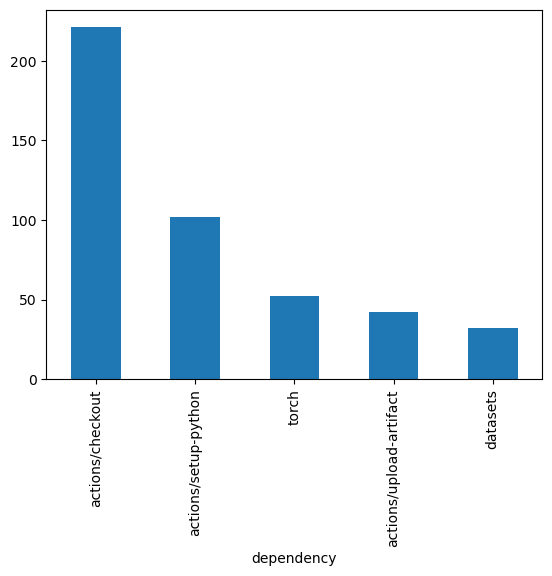

In [3]:
top5.plot(kind="bar")

In [4]:
data = []

for arch in vulnerabilidades:
    with open(arch) as archivo:
        j = json.load(archivo)

        repo = arch.split("/")[-1].replace(".json", "")

        for match in j.get("matches", []):
            vulnerabilidad = match.get("vulnerability", {})
            artifact = match.get("artifact", {})

            data.append({
                "repo": repo,
                "severity": vulnerabilidad.get("severity"),
                "vuln_id": vulnerabilidad.get("id"),
                "package": artifact.get("name")
            })

df = pd.DataFrame(data)

Análisis 2: Vulnerabilidad crítica más común

Este análisis permite identificar fallos de seguridad críticos que se encuentran presentes en múltiples repositorios dentro de la organización.

El objetivo es detectar vulnerabilidades recurrentes, lo que puede indicar el uso compartido de dependencias afectadas. Este tipo de análisis puede resultar fundamental ya que una misma vulnerabilidad en diversas dependencia puede amplificar su impacto, lo que representa una gran amenaza ante ataques externos.


In [5]:
critical_df = df[df["severity"] == "Critical"]

conteo_vuln = critical_df["vuln_id"].value_counts()

vulnerabilidad_comun = conteo_vuln.head(1)

vulnerabilidad_comun

vuln_id
GHSA-53q9-r3pm-6pq6    8
Name: count, dtype: int64

De acuerdo con el análisis, la vulnerabilidad crítica que más veces aparece en los repositorios tiene por ID "GHSA-53q9-r3pm-6pq6". Se encuentra replicada en diversos proyectos asociados a la organización, lo que podría indicar un uso compartido de dependencias afectadas.

Esta vulnerabilidad representa un riesgo significativo para la seguridad del software dada su clasificación como crítico, sobretodo si no se resuelve a tiempo y de manera adecuada en todos los repositorios que dependen de estas librerías afectadas.

Análisis 3: Repositorio con la mayor cantidad de vulnerabilidades críticas

Se busca identificar el repositorio que posea la mayor cantidad de vulnerabilidades críticas, lo que permite detectar proyectos que supongan un mayor riesgo de seguridad dentro de la organización.

Con este análisis es posible conocer qué repositorios requieren atención inmediata para tratar y resolver estos riesgos, especialmente en aquellos que dependen de librerías afectadas por vulnerabilidades de alta peligrosidad.

In [6]:
critical_df = df[df["severity"] == "Critical"]

repo_mas_critico = critical_df.groupby("repo").size()

repo_mas_critico = repo_mas_critico.sort_values(ascending=False)

repo_mas_critico.head(1)

repo
transformers-research-projects    7
dtype: int64

Tras este análisis, se obtiene que el repositorio "transformers-research-projects" contiene siete vulnerabilidades críticas, siendo el proyecto con mayor concentración de este tipo de riesgos dentro del conjunto analizado.

Como los repositorios comparten dependencias comunes, la existencia de múltiples vulnerabilidades en un solo proyecto puede incrementar el riesgo de propagación dentro del ecosistema de la organización, por lo que el repositorio "transformers-research-projects" resulta ser un punto crítico del ecosistema de software que requiere atención inmediata para poder solucionar todas estas vulnerabilidades.

Análisis 4: Top 10 repositorios con más vulnerabilidades totales

Este análisis busca encontrar los repositorios con mayor cantidad de vulnerabilidades en general, no solamente aquellos que son críticos. Esto ayuda a detectar proyectos con mayor exposición global a riesgos de seguridad.

Con estas consultas es posible priorizar esfuerzos de mitigación y tratamiento frente a vulnerabilidades de manera más abierta, no solo enfocándose en casos críticos sino a todo tipo de vulnerabilidades que supongan un riesgo, sin importar su severidad, para la organización.

In [7]:
repos_con_vulns = df.groupby("repo").size().sort_values(ascending=False)

repos_con_vulns.head(10)

repo
dataset-viewer                    552
transformers-research-projects    225
diffusers                          97
competitions                       60
doc-builder                        52
ml-intern                          42
lerobot                            41
autotrain-advanced                 38
datasets                           24
optimum-graphcore                  21
dtype: int64

Para obtener una visión más clara sobre la cantidad de vulnerabilidades presentes, esta información puede representarse mediante un gráfico. Esto permite identificar de manera más intuitiva la distribución de vulnerabilidades en el ecosistema.

A partir de este análisis, se obtiene que el repositorio "dataset-viewer" concentra la mayor cantidad de vulnerabilidades en general, por lo que podría requerir una mayor atención en términos de revisión y mitigación de riesgos.

<AxesSubplot: xlabel='repo'>

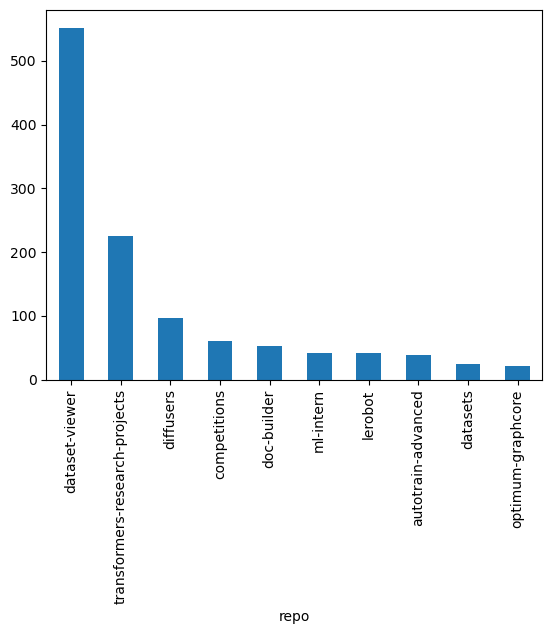

In [8]:
repos_con_vulns.head(10).plot(kind="bar")

In [9]:
deps = []

for archivo in archivos:
    with open(archivo) as arch:
        j = json.load(arch)

        repo = archivo.split("/")[-1].replace(".json", "")

        for art in j.get("artifacts", []):
            deps.append({
                "repo": repo,
                "dependency": art.get("name")
            })

dependencias_por_repo = pd.DataFrame(deps)

Análisis 5: Relación entre dependencias utilizadas y vulnerabilidades encontradas

Este análisis busca identificar una posible relación entre la cantidad de dependencias utilizadas en los repositorios y el número de vulnerabilidades identificadas en los proyectos.

A partir de esta consulta, es posible evaluar si los proyectos con mayor número de librerías tienden a presentar una mayor cantidad de vulnerabilidades, lo que podría indicar un aumento en la superficie de ataque del sistema y, por ende, un riesgo mayor para la organización.

In [10]:
dependencias_por_repo = dependencias_por_repo.groupby("repo").size()

vuln_por_repo = df.groupby("repo").size()

analisis_rel = pd.DataFrame({
    "dependencies": dependencias_por_repo,
    "vulnerabilities": vuln_por_repo
}).fillna(0)

analisis_rel

,dependencies,vulnerabilities
repo,,
accelerate,32,2.0
autotrain-advanced,62,38.0
competitions,45,60.0
dataset-viewer,2117,552.0
datasets,14,24.0
datatrove,661,18.0
diffusers,148,97.0
doc-builder,262,52.0
evaluate,12,0.0


Tras haber realizado esta consulta, no se logra apreciar una relación directa entre la cantidad de dependencias utilizadas por un repositorio y el número de vulnerabilidades detectadas. A pesar de que existen proyectos con un alto número de librerías que presentan una gran cantidad de vulnerabilidades presentes, se han logrado encontrar otros repositorios donde esto no se cumple.

Esto indica que la cantidad de vulnerabilidades no depende únicamente de cuántas dependencias se usan, sino también del estado de las librerías incorporadas. De esta forma, ciertas dependencias pueden introducir más riesgos que otras, sin importar la extensión del proyecto en sí

Para concluir, en este análisis se evaluaron las dependencias usadas y vulnerabilidades presentes en los repositorios de la organización Hugging Face, utilizando información generada a partir de SBOMs y escaneos de seguridad a partir del uso de herramientas como Syft y Grype. A partir de los resultados obtenidos, se identificó la presencia de dependencias comunes entre proyectos, así como vulnerabilidades recurrentes que afectan a múltiples repositorios.

De igual forma, se logró determinar qué repositorios concentran una mayor cantidad de vulnerabilidades, tanto críticas como generales, lo que permite priorizar esfuerzos de tratamiento y enfrentamiento en aquellos proyectos con mayor exposición al riesgo de ataques externos.

Finalmente, el análisis de la relación entre dependencias y vulnerabilidades sugiere que no existe una correlación directa entre la cantidad de librerías utilizadas y el número de vulnerabilidades detectadas. En cambio, se evidencia que el riesgo está fuertemente relacionado con la naturaleza y estado de las librerías utilizadas, lo que resalta la importancia de una adecuada gestión y actualización de las mismas dentro del ciclo de desarrollo, con el objetivo de asegurar el ecosistema de software.